# Notebook 02 — Construction du graphe financier

**Objectif** : Transformer la matrice de corrélation en un objet graphe exploitable par PyTorch Geometric.

**Concepts clés** :
- Graphe G = (V, E) : nœuds = actifs, arêtes = corrélations fortes
- `edge_index` : représentation sparse PyG (2 × n_arêtes)
- Graphe statique vs dynamique (rolling correlations)
- Visualisation avec NetworkX

**Référence** : Kipf & Welling (2017) — Semi-supervised classification with GCN

In [8]:
import sys, os
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

from src.data_loader import DataLoader, DJIA_SECTORS
from src.graph_builder import GraphBuilder

# Charger les données
prices  = pd.read_parquet('../data/prices.parquet')
returns = pd.read_parquet('../data/returns.parquet')
print(f"Données chargées : {returns.shape}")

Données chargées : (1508, 28)


## 1. Choix du seuil de corrélation

Le seuil détermine quelles paires d'actifs sont connectées dans le graphe.
- **Trop bas** (< 0.2) : graphe trop dense, bruit capturé
- **Trop haut** (> 0.6) : graphe trop sparse, structure perdue
- **Optimal** : ~0.3–0.4 pour le DJIA (actifs diversifiés)

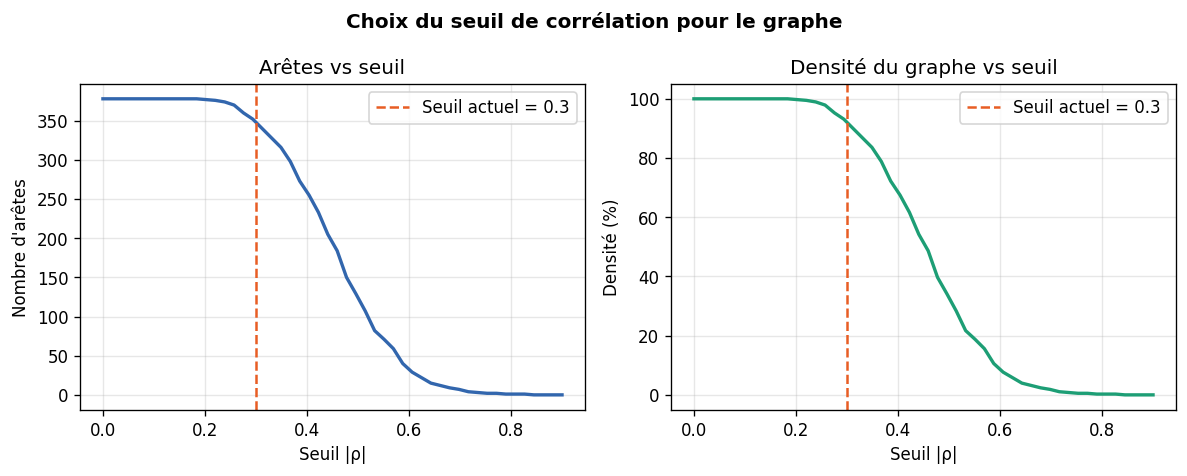

In [9]:
builder = GraphBuilder(returns, threshold=0.3, sectors=DJIA_SECTORS)
fig = builder.plot_correlation_threshold_analysis()
plt.savefig('../data/04_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Construction du graphe statique

In [10]:
loader = DataLoader(tickers=list(returns.columns), start='2018-01-01', end='2023-12-31')
loader.prices  = prices
loader.returns = returns

# Features initiales des nœuds
X = loader.build_node_features(window=20)

# Construire le graphe
graph_data = builder.build_static_graph(X)

print("\n── Structure du graphe PyTorch Geometric ──")
print(f"graph_data.x          : {graph_data.x.shape}  (nœuds × features)")
print(f"graph_data.edge_index  : {graph_data.edge_index.shape}  (2 × arêtes)")
print(f"graph_data.edge_attr   : {graph_data.edge_attr.shape}  (poids arêtes)")

print("\n── Inspection des premières arêtes ──")
tickers = list(returns.columns)
for i in range(min(5, graph_data.edge_index.shape[1])):
    src = graph_data.edge_index[0, i].item()
    dst = graph_data.edge_index[1, i].item()
    w   = graph_data.edge_attr[i, 0].item()
    print(f"  {tickers[src]} ──({w:.3f})──> {tickers[dst]}")

[DataLoader] ✓ Features nœuds : (28, 5) (5 features par actif)
[GraphBuilder] Graphe statique :
  Nœuds   : 28
  Arêtes  : 350 paires (threshold=0.3)
  Densité : 92.6%
  Features: 5 par nœud

── Structure du graphe PyTorch Geometric ──
graph_data.x          : torch.Size([28, 5])  (nœuds × features)
graph_data.edge_index  : torch.Size([2, 700])  (2 × arêtes)
graph_data.edge_attr   : torch.Size([700, 1])  (poids arêtes)

── Inspection des premières arêtes ──
  AAPL ──(0.418)──> AMGN
  AAPL ──(0.483)──> AXP
  AAPL ──(0.434)──> BA
  AAPL ──(0.414)──> CAT
  AAPL ──(0.589)──> CRM


## 3. Visualisation du graphe

**À observer** :
- Les actifs du même secteur se regroupent naturellement
- JPM, GS, AXP (Finance) forment un cluster dense
- Les actifs techs (AAPL, MSFT, CSCO) sont fortement connectés
- CVX (énergie) est plus isolé → opportunité de diversification

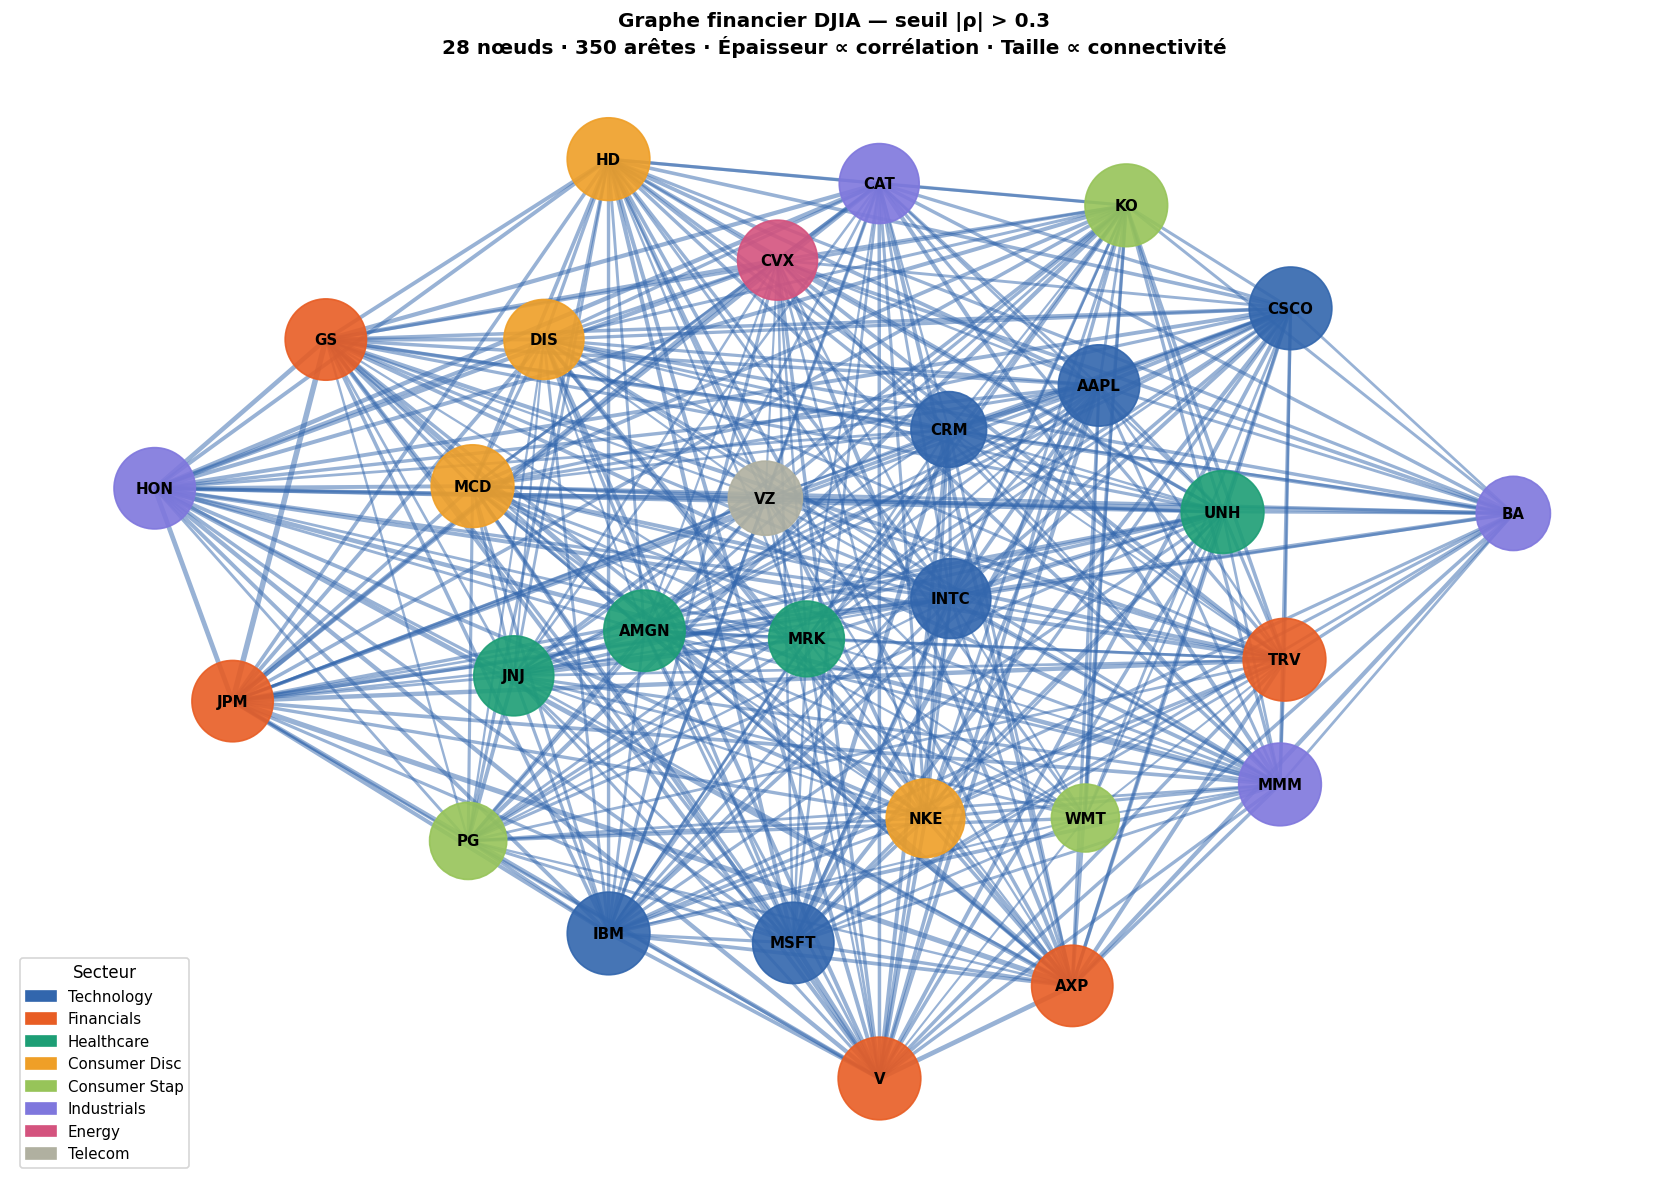

In [11]:
fig = builder.plot_graph(figsize=(14, 10))
plt.savefig('../data/05_financial_graph.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Graphe dynamique — rolling correlations (niveau excellent)

La corrélation entre actifs **change dans le temps** :
- En période de crise (mars 2020) : toutes les corrélations montent vers 1
- En période normale : clusters sectoriels bien définis

On construit un graphe différent toutes les `step` jours.

In [12]:
def compute_features_for_window(window_returns):
    """Calcule les features de nœuds pour une fenêtre donnée."""
    features = []
    for ticker in window_returns.columns:
        r = window_returns[ticker]
        features.append([
            r.mean(),
            r.std(),
            r.sum(),
            r.skew() if len(r) > 3 else 0.0,
            0.0,  # secteur (simplifié)
        ])
    return np.array(features, dtype=np.float32)

# Construire les graphes dynamiques (fenêtre 60j, step 20j)
dynamic_graphs = builder.build_dynamic_graphs(
    node_features_fn = compute_features_for_window,
    window = 60,
    step   = 20,
)

print(f"\n{len(dynamic_graphs)} graphes construits")
print(f"Premier : {dynamic_graphs[0][0].date()}")
print(f"Dernier : {dynamic_graphs[-1][0].date()}")

[GraphBuilder] Graphes dynamiques : 73 fenêtres × 60j (step=20j)
[GraphBuilder] ✓ 73 graphes construits

73 graphes construits
Premier : 2018-03-29
Dernier : 2023-12-18


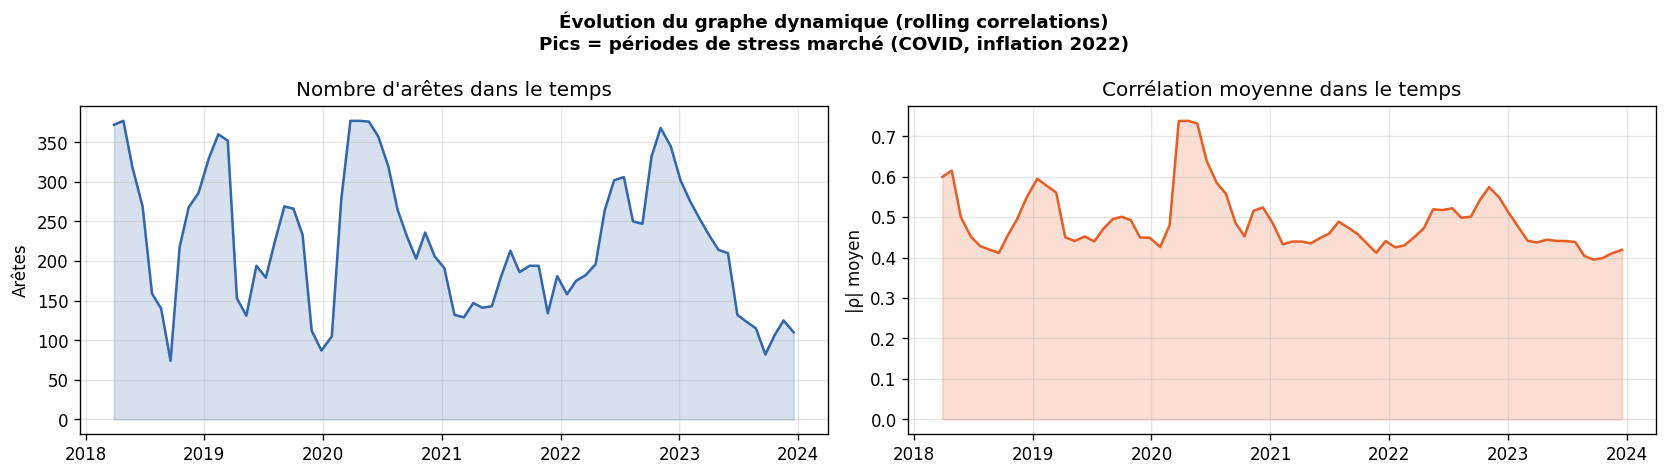


Pic de connectivité : 2018-04-27 (377 arêtes) — probablement crise COVID


In [13]:
fig = builder.plot_dynamic_graph_evolution(dynamic_graphs)
plt.savefig('../data/06_dynamic_graph_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

# Identifier le pic de corrélation (vraisemblablement COVID mars 2020)
edge_counts = [g.edge_index.shape[1]//2 for _, g in dynamic_graphs]
peak_idx    = np.argmax(edge_counts)
print(f"\nPic de connectivité : {dynamic_graphs[peak_idx][0].date()} "
      f"({edge_counts[peak_idx]} arêtes) — probablement crise COVID")

## 5. Sauvegarde

In [ ]:
import torch
torch.save(graph_data, '../data/static_graph.pt')
torch.save(dynamic_graphs, '../data/dynamic_graphs.pt')

print("✓ Graphes sauvegardés")

✓ Graphes sauvegardés
Prochain notebook : 03_gnn_model.ipynb
